# Learned Feature Analysis (Latest Checkpoint)

## What I Probe First
1. **Routing/query validity**: how often mapped HR pixels use boundary/mismatched LR parent queries.
2. **Learned parameter drift**: what changed in the upsampler (`log_grain_attn_temp`, `pos_bias`, `spatial_weights`, `tp`).
3. **Seed-attention behavior**: sharpness/locality via top-1 mass, normalized entropy, expected LR distance.
4. **Concrete probe visuals**: random HR pixels with LR attention heatmaps.

This order isolates pipeline correctness before model behavior.

## What These Plots Tell Us (Current Run)
- Learning is concentrated in the **upsample** stage; LR/HR conv stages show little to no drift in this config.
- `upsample_conv.spatial_weights` is the dominant change over training (largest drift by far).
- The upsample kernel becomes more concentrated/local with training:
  - center-to-uniform ratio rises (about `1.05 -> 5.21` from epoch 5 to last),
  - normalized entropy drops (about `1.00 -> 0.955`),
  - mean kernel radius drops (about `12.57 -> 9.48`).
- Grain-attention sharpness increases:
  - `exp(log_grain_attn_temp)` grows to about `2.98`.
- Context mixing strength increases:
  - `upsample_conv.tp.weight` grows roughly `0.29 -> 1.42`.
- Positional-bias behavior changes qualitatively:
  - `pos_bias.weight` flips sign (about `-0.0538 -> +0.0586` from epoch 5 to last),
  - interpretation: the model shifts from penalizing farther same-grain candidates to allowing/rewarding broader same-grain context when useful.

Overall, these plots show a clear learned strategy: stronger and sharper attention, plus a more structured upsample kernel that still uses broader within-grain context when it helps.




In [48]:
# Setup + load latest checkpoint
from __future__ import annotations
import gc
import importlib
import inspect
import json
import os
import sys
from pathlib import Path
import numpy as np
import torch


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "experiments").exists() and (p / "models").exists() and (p / "training").exists():
            return p
    raise FileNotFoundError(
        f"Could not find repo root from {start}; expected experiments/, models/, training/"
    )


def _safe_mem_get_info(idx: int) -> tuple[int, int] | None:
    try:
        free_b, total_b = torch.cuda.mem_get_info(idx)
        return int(free_b), int(total_b)
    except RuntimeError as e:
        msg = str(e).lower()
        if "cuda" in msg or "out of memory" in msg:
            print(f"[warning] CUDA memory probe failed for device {idx}: {e}")
            return None
        raise


def visible_cuda_memory_rows() -> list[tuple[int, int, int]]:
    rows: list[tuple[int, int, int]] = []
    if not torch.cuda.is_available():
        return rows
    for i in range(torch.cuda.device_count()):
        info = _safe_mem_get_info(i)
        if info is None:
            continue
        free_b, total_b = info
        rows.append((i, free_b, total_b))
    return rows


def pick_device(min_free_gb: float = 2.0) -> torch.device:
    if str(os.environ.get("ANALYSIS_FORCE_CPU", "")).strip().lower() in {"1", "true", "yes", "y"}:
        print("ANALYSIS_FORCE_CPU is set; using CPU.")
        return torch.device("cpu")

    if not torch.cuda.is_available():
        return torch.device("cpu")

    rows = visible_cuda_memory_rows()
    min_free_b = int(float(min_free_gb) * (1024 ** 3))

    pref = os.environ.get("ANALYSIS_CUDA_INDEX", "").strip()
    if pref.isdigit():
        idx = int(pref)
        if 0 <= idx < torch.cuda.device_count():
            info = _safe_mem_get_info(idx)
            if info is not None:
                free_b, _ = info
                if free_b >= min_free_b:
                    return torch.device(f"cuda:{idx}")
                print(
                    f"ANALYSIS_CUDA_INDEX={idx} has low free memory: {free_b/1024**3:.2f} GB; auto-selecting another device."
                )
            else:
                print(f"ANALYSIS_CUDA_INDEX={idx} is not usable right now; auto-selecting another device.")

    if len(rows) == 0:
        print("[warning] Could not safely query visible CUDA devices. Falling back to CPU.")
        return torch.device("cpu")

    # If no explicit analysis override, pick the visible GPU with most free memory.
    best_idx, best_free, _ = max(rows, key=lambda t: t[1])
    if best_free < min_free_b:
        print(
            f"Best visible CUDA device has only {best_free/1024**3:.2f} GB free (< {min_free_gb:.2f} GB). Falling back to CPU."
        )
        return torch.device("cpu")
    return torch.device(f"cuda:{best_idx}")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

EXP_DIR = REPO_ROOT / "experiments" / "IN718" / "iso_embedding_sr_attn_boundary_aware_01"
if not EXP_DIR.exists():
    candidates = sorted((REPO_ROOT / "experiments" / "IN718").glob("iso_embedding_sr_attn_boundary_aware_*"))
    if not candidates:
        raise FileNotFoundError(
            f"No boundary-aware IN718 experiment dir found under {REPO_ROOT / 'experiments' / 'IN718'}"
        )
    EXP_DIR = candidates[-1]

cfg_candidates = [
    EXP_DIR / "logs" / "run_config.json",
    EXP_DIR / "config_new.json",
]
CFG_PATH = next((p for p in cfg_candidates if p.exists()), None)
if CFG_PATH is None:
    tried = " ; ".join(str(p) for p in cfg_candidates)
    raise FileNotFoundError(f"Could not find config. Tried: {tried}")

CKPT_DIR = EXP_DIR / "checkpoints"
if not CKPT_DIR.exists():
    raise FileNotFoundError(f"Checkpoint directory not found: {CKPT_DIR}")

cfg = json.loads(CFG_PATH.read_text())


def resolve_latest_ckpt(ckpt_dir: Path) -> Path:
    p = ckpt_dir / "last_checkpoint.pt"
    if p.exists():
        return p
    pts = sorted(ckpt_dir.glob("*.pt"), key=lambda x: x.stat().st_mtime, reverse=True)
    if not pts:
        raise FileNotFoundError(f"No checkpoints in {ckpt_dir}")
    return pts[0]


def build_model(cfg: dict, device: torch.device):
    model_cfg = cfg.get("model", {}) or {}
    mod_name = model_cfg.get("module", "models.SR_double_conv_SRattn_a1_Boundary_aware")
    cls_name = model_cfg.get("class", "IsoEmbeddingSRAttn")
    mod = importlib.import_module(mod_name)
    cls = getattr(mod, cls_name)

    sig = inspect.signature(cls.__init__).parameters
    kwargs = {
        k: v for k, v in cfg.items()
        if k in sig and k not in {"self", "args", "kwargs"}
    }
    kwargs.update({
        k: v for k, v in model_cfg.items()
        if k in sig and k not in {"self", "args", "kwargs", "module", "class"}
    })

    # Force explicit device so ctor does not silently default to cuda:0.
    kwargs["device"] = str(device)

    # Force decoder cache dir absolute at repo root so we reuse prebuilt tables.
    cache_dir = kwargs.get("decoder_table_cache_dir", cfg.get("decoder_table_cache_dir", "out/decoder_lookup_tables"))
    if cache_dir is not None:
        cpath = Path(cache_dir)
        if not cpath.is_absolute():
            cpath = (REPO_ROOT / cpath).resolve()
        kwargs["decoder_table_cache_dir"] = str(cpath)

    model = cls(**kwargs).to(device)
    return model, kwargs


def init_model_with_fallback(cfg: dict, device: torch.device, ckpt_path: Path):
    try:
        model, model_kwargs = build_model(cfg, device)
        payload = torch.load(ckpt_path, map_location=device)
        state = payload.get("model_state", payload)
        missing, unexpected = model.load_state_dict(state, strict=False)
        model.eval()
        return model, model_kwargs, device, missing, unexpected
    except RuntimeError as e:
        if device.type == "cuda" and "out of memory" in str(e).lower():
            print(f"CUDA OOM while building model on {device}. Falling back to CPU for analysis.")
            gc.collect()
            torch.cuda.empty_cache()
            cpu = torch.device("cpu")
            model, model_kwargs = build_model(cfg, cpu)
            payload = torch.load(ckpt_path, map_location=cpu)
            state = payload.get("model_state", payload)
            missing, unexpected = model.load_state_dict(state, strict=False)
            model.eval()
            return model, model_kwargs, cpu, missing, unexpected
        raise


min_free_gb = float(cfg.get("analysis_min_free_cuda_gb", 2.0))
device = pick_device(min_free_gb=min_free_gb)
if device.type == "cuda":
    torch.cuda.set_device(device)
    torch.cuda.empty_cache()

ckpt_path = resolve_latest_ckpt(CKPT_DIR)
model, model_kwargs, device, missing, unexpected = init_model_with_fallback(cfg, device, ckpt_path)

print("REPO_ROOT:", REPO_ROOT)
print("Config:", CFG_PATH)
print("Checkpoint:", ckpt_path)
print("Device:", device)
print("Decoder cache dir:", model_kwargs.get("decoder_table_cache_dir"))
if torch.cuda.is_available():
    rows = visible_cuda_memory_rows()
    pretty = [f"cuda:{i} free={free/1024**3:.2f}GB/{total/1024**3:.2f}GB" for i, free, total in rows]
    print("Visible CUDA memory:", " | ".join(pretty))
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))




[warning] CUDA memory probe failed for device 0: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



/tmp/ipykernel_1243496/3402558841.py:163: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(ckpt_path, map_location=device)


REPO_ROOT: /data/home/umang/Materials/Reynolds-QSR_4x1
Config: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_sr_attn_boundary_aware_01/logs/run_config.json
Checkpoint: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_sr_attn_boundary_aware_01/checkpoints/last_checkpoint.pt
Device: cuda:6
Decoder cache dir: /data/home/umang/Materials/Reynolds-QSR_4x1/out/decoder_lookup_tables
[warning] CUDA memory probe failed for device 0: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Visible CUDA memory: cuda:1 free=38.86GB/39.38GB | cuda:2 free=38.86GB/39.38GB | cuda:3 free=38.86GB/39.38GB | cuda:4 free=38.86GB/39.38GB | cuda:5 free=38.82GB/39.38GB | cuda:6 free=38.75GB/39.38GB | cuda:7 free=38.97GB/39.38GB
Missing keys: 23
U

In [49]:
# Dataset + core probes (routing/query validity + parameter drift)
import pandas as pd
from training.quaternion_dataset import QuaternionDataset

split = cfg.get("analysis_split", "Val")
ds = QuaternionDataset(
    dataset_root=cfg["dataset_root"],
    split=split,
    return_lr_boundary_map=True,
    lr_boundary_angle_deg=float(cfg.get("lr_boundary_angle_deg", 5.0)),
    lr_boundary_mark_both_sides=bool(cfg.get("lr_boundary_mark_both_sides", True)),
)

def to_n4(q: torch.Tensor):
    if q.ndim != 3:
        raise ValueError(tuple(q.shape))
    if q.shape[0] == 4:
        H, W = int(q.shape[1]), int(q.shape[2])
        return q.permute(1,2,0).reshape(1, H*W, 4).float(), (H, W)
    if q.shape[-1] == 4:
        H, W = int(q.shape[0]), int(q.shape[1])
        return q.reshape(1, H*W, 4).float(), (H, W)
    raise ValueError(tuple(q.shape))

@torch.no_grad()
def context_stats(i: int):
    lr, hr, bmap = ds[i]
    _, (H, W) = to_n4(lr)
    ctx = model._prepare_boundary_context(
        lr_boundary_map=bmap.to(device=device, dtype=torch.float32),
        lr_shape=(H, W),
        batch_size=1,
        device=device,
        dtype=torch.float32,
    )
    hr_to_lr = ctx["hr_to_lr_map"][0].to(torch.long).cpu()
    lr_labels = ctx["lr_labels"][0].to(torch.long).cpu()

    Hr, Wr = hr_to_lr.shape
    r_h, r_w = Hr // H, Wr // W
    y = torch.arange(Hr, dtype=torch.long)
    x = torch.arange(Wr, dtype=torch.long)
    gy, gx = torch.meshgrid(y, x, indexing="ij")
    py = torch.div(gy, r_h, rounding_mode="floor").clamp(0, H-1)
    px = torch.div(gx, r_w, rounding_mode="floor").clamp(0, W-1)

    mapped = hr_to_lr >= 0
    parent = lr_labels[py, px]
    mapped_n = max(1, int(mapped.sum().item()))

    return {
        "sample_idx": i,
        "fallback_hr_frac": float((~mapped).float().mean().item()),
        "parent_boundary_frac_mapped": float((((parent < 0) & mapped).sum().item()) / mapped_n),
        "parent_gid_mismatch_frac_mapped": float((((parent >= 0) & mapped & (parent != hr_to_lr)).sum().item()) / mapped_n),
    }

N = min(64, len(ds))
df_ctx = pd.DataFrame([context_stats(i) for i in range(N)])
print("Split:", split, "Num samples:", len(ds), "Probed:", N)
display(df_ctx.describe().T)

# Parameter drift in upsampler
fresh_model, _ = build_model(cfg, torch.device("cpu"))  # keep fresh model off GPU
fresh = fresh_model.state_dict()
trained = model.state_dict()
rows = []
for k, v in trained.items():
    if not k.startswith("upsample_conv.") or k not in fresh:
        continue
    d = (v - fresh[k].to(v.device, dtype=v.dtype)).float()
    rows.append({
        "param": k,
        "shape": tuple(v.shape),
        "delta_l2": float(torch.linalg.norm(d).item()),
        "delta_mean_abs": float(d.abs().mean().item()),
        "trained_mean": float(v.float().mean().item()),
        "trained_std": float(v.float().std().item()) if v.numel() > 1 else 0.0,
    })
df_param = pd.DataFrame(rows).sort_values("delta_l2", ascending=False)
display(df_param.reset_index(drop=True))


Split: Val Num samples: 147 Probed: 64


,count,mean,std,min,25%,50%,75%,max
sample_idx,64.0,31.500000,18.618987,0.000000,15.750000,31.500000,47.250000,63.000000
fallback_hr_frac,64.0,0.045427,0.014717,0.022583,0.034439,0.044830,0.053085,0.094238
parent_boundary_frac_mapped,64.0,0.134612,0.043264,0.063569,0.102465,0.131604,0.154433,0.284012
parent_gid_mismatch_frac_mapped,64.0,0.000763,0.000755,0.000000,0.000255,0.000543,0.000908,0.003501


,param,shape,delta_l2,delta_mean_abs,trained_mean,trained_std
0,upsample_conv.tp.weight,"(1,)",0.961611,0.961611,0.203278,0.000000
1,upsample_conv.spatial_weights,"(33, 33)",0.000000,0.000000,0.000918,0.000000
2,upsample_conv.log_grain_attn_temp,(),0.000000,0.000000,0.000000,0.000000
3,upsample_conv.pos_bias.weight,"(1, 1)",0.000000,0.000000,0.000000,0.000000
4,upsample_conv.pos_bias.bias,"(1,)",0.000000,0.000000,0.000000,0.000000
5,upsample_conv.tp.output_mask,"(9,)",0.000000,0.000000,1.000000,0.000000
6,upsample_conv.tp._compiled_main_left_right._w3...,"(9, 9, 9)",0.000000,0.000000,0.000349,0.037061


{'sample_idx': 0, 'n_queries': 15839, 'top1_mean': 0.013581420294940472, 'entropy_mean_norm': 0.9993430972099304, 'expected_distance_lr_mean': 7.499761581420898}


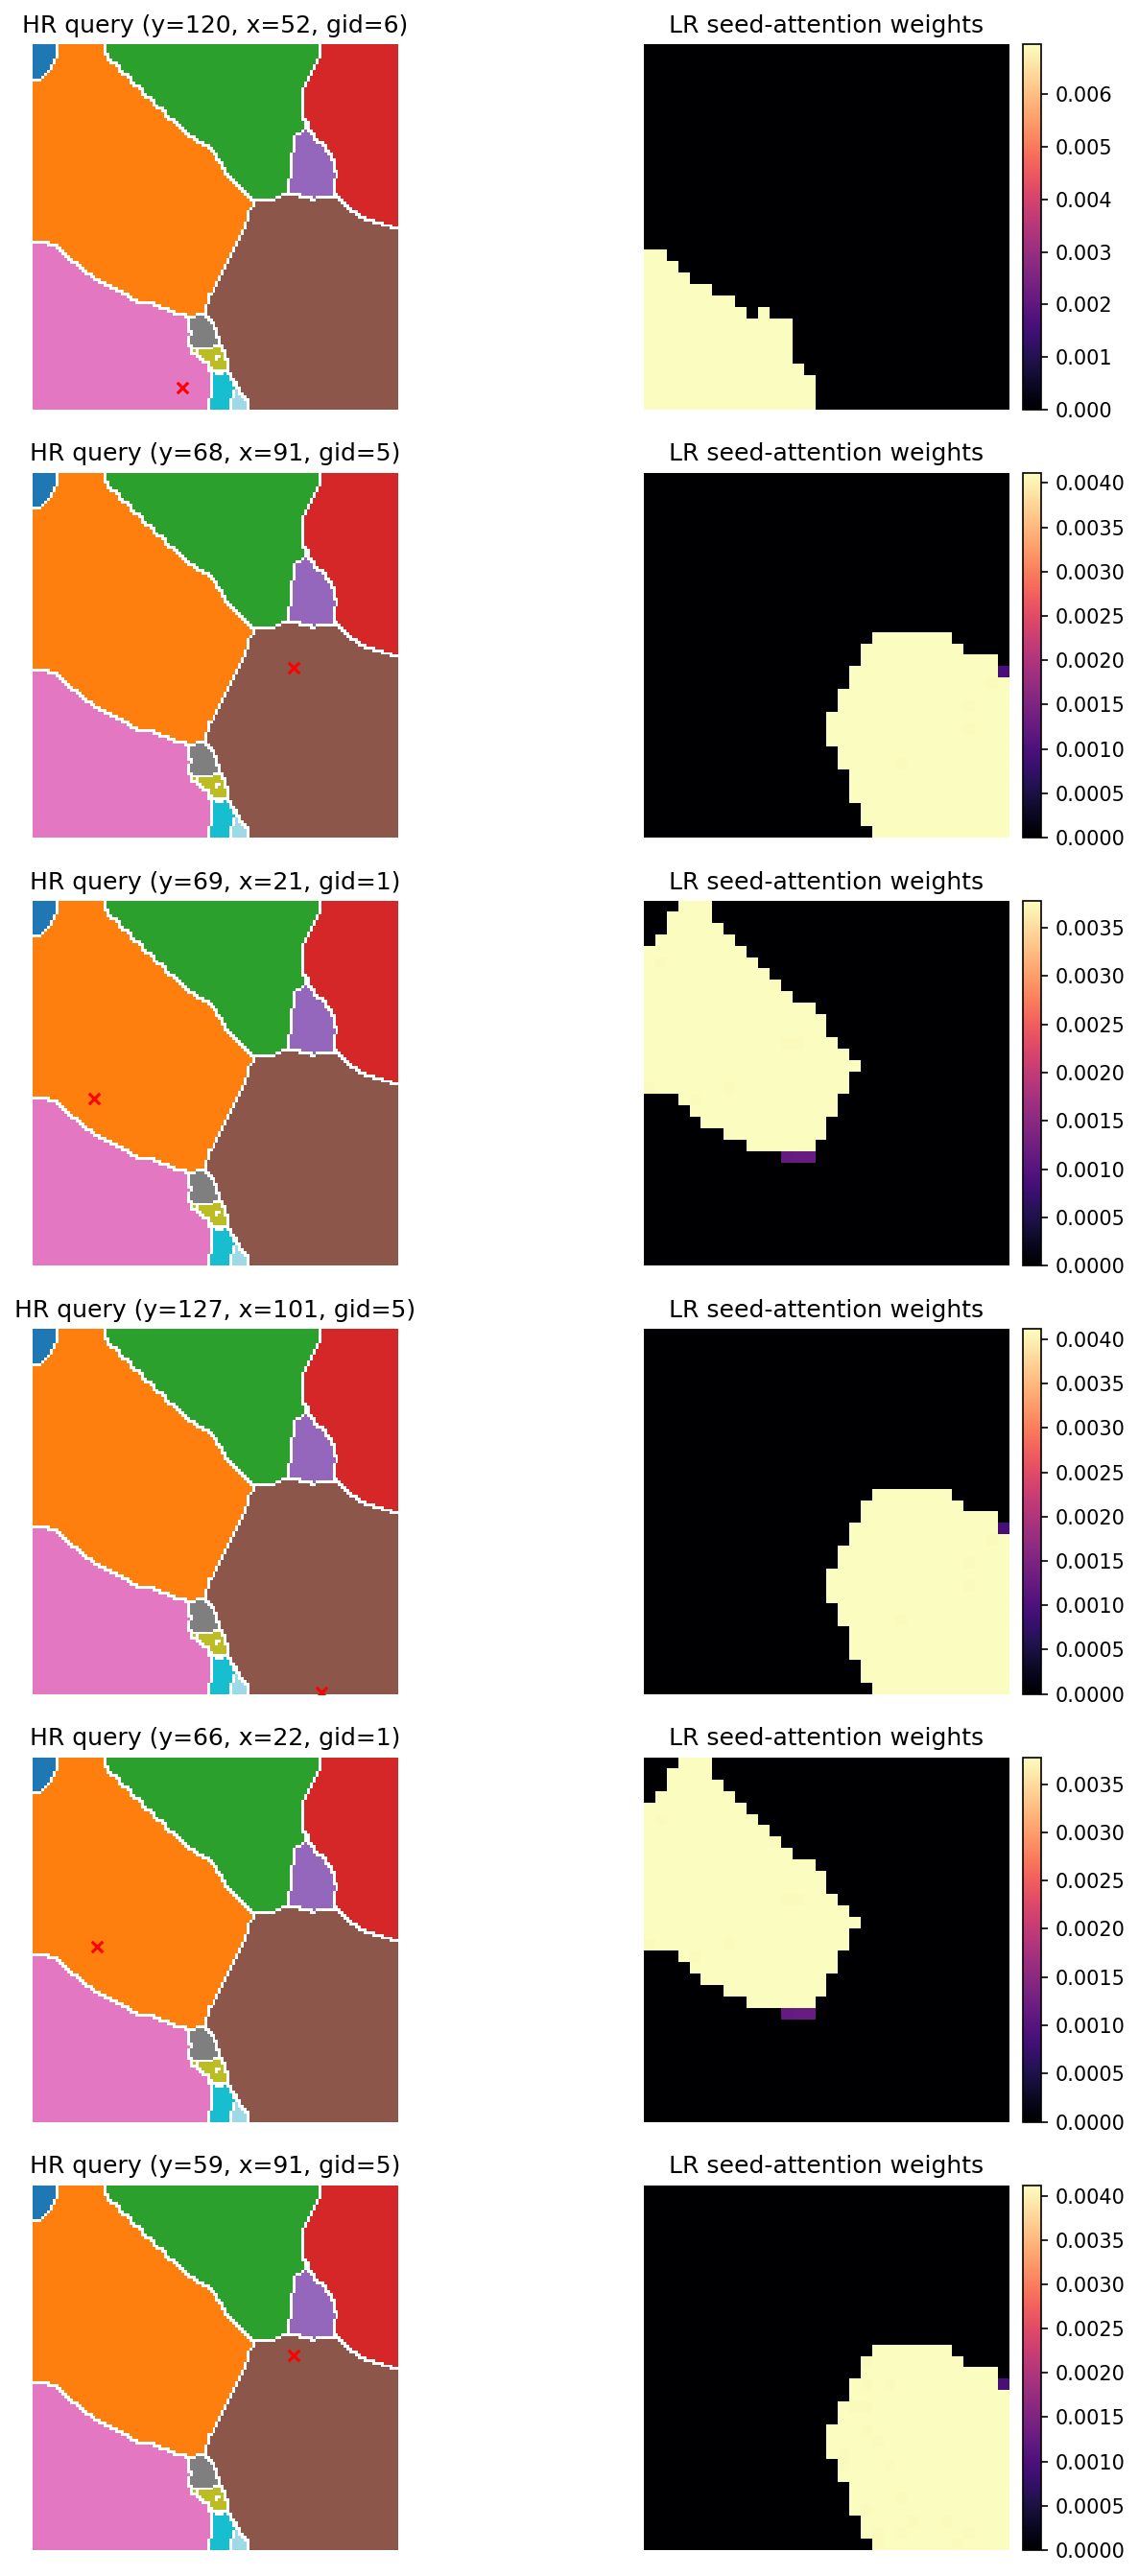

In [50]:
# Seed-attention sharpness/locality + random probe heatmaps
import math
import matplotlib.pyplot as plt

@torch.no_grad()
def seed_attention_stats_and_plots(sample_idx: int = 0, n_probes: int = 6):
    lr, hr, bmap = ds[sample_idx]
    lrq, (H, W) = to_n4(lr)
    lrq = lrq.to(device=device)

    feat_lr = model.encode_a1(lrq.reshape(-1, 4)).reshape(1, H * W, -1)
    C = feat_lr.shape[-1]
    feat_lr_img = feat_lr.view(1, H, W, C).permute(0,3,1,2)

    ctx = model._prepare_boundary_context(
        lr_boundary_map=bmap.to(device=device, dtype=torch.float32),
        lr_shape=(H, W),
        batch_size=1,
        device=device,
        dtype=torch.float32,
    )
    hr_to_lr = ctx["hr_to_lr_map"][0].to(torch.long)
    lr_labels = ctx["lr_labels"][0].to(torch.long)

    up = model.upsample_conv
    Hr, Wr = hr_to_lr.shape
    r_h, r_w = up.upsample_factor

    y = torch.arange(Hr, device=device, dtype=torch.long)
    x = torch.arange(Wr, device=device, dtype=torch.long)
    gy, gx = torch.meshgrid(y, x, indexing="ij")
    parent_y = torch.div(gy, r_h, rounding_mode="floor").clamp(0, H-1)
    parent_x = torch.div(gx, r_w, rounding_mode="floor").clamp(0, W-1)
    parent_idx = (parent_y * W + parent_x).reshape(-1)

    qy_lr = (gy.reshape(-1).float() + 0.5) / float(r_h) - 0.5
    qx_lr = (gx.reshape(-1).float() + 0.5) / float(r_w) - 0.5
    q_coords_all = torch.stack([qx_lr, qy_lr], dim=-1).to(device=device, dtype=feat_lr_img.dtype)

    k_all = feat_lr_img[0].permute(1,2,0).reshape(H*W, C)
    map_flat = hr_to_lr.reshape(-1)
    lr_flat = lr_labels.reshape(-1)
    attn_temp = torch.exp(up.log_grain_attn_temp)

    top1_all, ent_all, expd_all = [], [], []

    for gid in torch.unique(map_flat[map_flat >= 0]).tolist():
        q_idx = (map_flat == int(gid)).nonzero(as_tuple=False).squeeze(1)
        k_idx = (lr_flat == int(gid)).nonzero(as_tuple=False).squeeze(1)
        if q_idx.numel() == 0 or k_idx.numel() == 0:
            continue

        parent_idx_q = parent_idx[q_idx]
        q = k_all[parent_idx_q]
        k = k_all[k_idx]

        parent_gid_q = lr_flat[parent_idx_q]
        bad_parent = parent_gid_q != int(gid)

        k_y = torch.div(k_idx, W, rounding_mode="floor").to(feat_lr_img.dtype)
        k_x = torch.remainder(k_idx, W).to(feat_lr_img.dtype)
        k_coords = torch.stack([k_x, k_y], dim=-1)

        if bool(bad_parent.any()):
            bad_local = bad_parent.nonzero(as_tuple=False).squeeze(1)
            d_bad = torch.cdist(q_coords_all[q_idx[bad_local]], k_coords, p=2)
            nn_bad = torch.argmin(d_bad, dim=-1)
            q = q.clone()
            q[bad_local] = k[nn_bad]

        scores = attn_temp * up._invariant_grain_scores(q, k)
        d = torch.cdist(q_coords_all[q_idx], k_coords, p=2)
        scores = scores + up.pos_bias(d.unsqueeze(-1)).squeeze(-1)
        attn = torch.softmax(scores.float(), dim=-1).to(scores.dtype)

        top1 = attn.max(dim=-1).values
        top1_all.append(top1.detach().cpu())
        if attn.shape[-1] > 1:
            ent = -(attn * torch.log(attn.clamp_min(1e-12))).sum(dim=-1) / math.log(int(attn.shape[-1]))
        else:
            ent = torch.zeros(attn.shape[0], device=attn.device, dtype=attn.dtype)
        ent_all.append(ent.detach().cpu())
        expd = (attn * d.to(attn.dtype)).sum(dim=-1)
        expd_all.append(expd.detach().cpu())

    top1_all = torch.cat(top1_all) if len(top1_all) else torch.tensor([])
    ent_all = torch.cat(ent_all) if len(ent_all) else torch.tensor([])
    expd_all = torch.cat(expd_all) if len(expd_all) else torch.tensor([])

    print({
        "sample_idx": sample_idx,
        "n_queries": int(top1_all.numel()),
        "top1_mean": float(top1_all.mean()) if top1_all.numel() else float("nan"),
        "entropy_mean_norm": float(ent_all.mean()) if ent_all.numel() else float("nan"),
        "expected_distance_lr_mean": float(expd_all.mean()) if expd_all.numel() else float("nan"),
    })

    # Random probes with LR weight heatmaps
    valid = (map_flat >= 0).nonzero(as_tuple=False).squeeze(1)
    if valid.numel() == 0:
        print("No mapped HR pixels")
        return
    rng = np.random.default_rng()
    take = min(n_probes, int(valid.numel()))
    picked = valid[rng.choice(valid.numel(), size=take, replace=False)]

    hr_map_np = hr_to_lr.detach().cpu().numpy().astype(float)
    hr_map_np[hr_map_np < 0] = np.nan

    fig, axes = plt.subplots(take, 2, figsize=(9, 3*take), dpi=150)
    if take == 1:
        axes = np.array([axes])

    for r, flat_idx in enumerate(picked.tolist()):
        y_hr = flat_idx // Wr
        x_hr = flat_idx % Wr
        gid = int(map_flat[flat_idx].item())

        q_idx = torch.tensor([flat_idx], device=device, dtype=torch.long)
        k_idx = (lr_flat == gid).nonzero(as_tuple=False).squeeze(1)
        q_parent_idx = parent_idx[q_idx]
        q = k_all[q_parent_idx]
        k = k_all[k_idx]

        parent_gid = lr_flat[q_parent_idx]
        bad_parent = parent_gid != gid
        k_y = torch.div(k_idx, W, rounding_mode="floor").to(feat_lr_img.dtype)
        k_x = torch.remainder(k_idx, W).to(feat_lr_img.dtype)
        k_coords = torch.stack([k_x, k_y], dim=-1)
        if bool(bad_parent.any()):
            d_bad = torch.cdist(q_coords_all[q_idx], k_coords, p=2)
            nn_bad = torch.argmin(d_bad, dim=-1)
            q = q.clone()
            q[0] = k[nn_bad[0]]

        scores = attn_temp * up._invariant_grain_scores(q, k)
        d = torch.cdist(q_coords_all[q_idx], k_coords, p=2)
        scores = scores + up.pos_bias(d.unsqueeze(-1)).squeeze(-1)
        attn = torch.softmax(scores.float(), dim=-1)[0]

        heat = torch.zeros(H * W, device=device, dtype=attn.dtype)
        heat[k_idx] = attn
        heat = heat.reshape(H, W).detach().cpu().numpy()

        ax_hr, ax_lr = axes[r]
        ax_hr.imshow(hr_map_np, cmap="tab20", interpolation="nearest")
        ax_hr.scatter([x_hr], [y_hr], c="red", s=30, marker="x")
        ax_hr.set_title(f"HR query (y={y_hr}, x={x_hr}, gid={gid})")
        ax_hr.axis("off")

        im = ax_lr.imshow(heat, cmap="magma", interpolation="nearest")
        ax_lr.set_title("LR seed-attention weights")
        ax_lr.axis("off")
        fig.colorbar(im, ax=ax_lr, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()

seed_attention_stats_and_plots(sample_idx=0, n_probes=6)


## How To Read The Learning Plots

Use these cells as a sequence to understand *what* changed and *how* it changed during training:

1. **Checkpoint trajectory (next cell)**
   - Shows scalar trends vs epoch.
   - Focus on: `temp`, `pos_w`, `tp_up`, `kernel_center_ratio`, `kernel_entropy_norm`, `kernel_mean_radius`.
   - Interpretation: rising `temp` and `center_ratio` with falling entropy/radius means attention and kernel mass are concentrating.

2. **Kernel evolution heatmaps**
   - Top row: softmax-normalized upsample kernels at representative epochs.
   - Bottom row: raw-kernel change relative to the first shown epoch.
   - Interpretation: brighter center and structured drift indicate where spatial aggregation is being learned.

3. **Radial-profile evolution**
   - Left: ring-wise mean probability by radius.
   - Right: cumulative mass within radius.
   - Interpretation: curves shifting upward at small radii indicate stronger locality; flatter/later rise means broader context usage.

4. **Positional-bias behavior + coupling**
   - Left: learned bias function `pos_bias(d)` over epochs (`y = w*d + b`).
   - Right: relationship between attention temperature and center concentration.
   - Interpretation: sign/slope changes in `pos_w` reflect whether distance is penalized or rewarded in grain attention.

Tip: compare these plots with your config flags (`use_lr_conv*`, `use_hr_conv1`, `use_attention`) so you interpret changes only in active stages.



/tmp/ipykernel_1243496/282732307.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location="cpu")


,epoch,temp,pos_w,pos_b,tp_up,tp_lr1,tp_lr2,tp_lr3,tp_hr1,kernel_center_prob,kernel_center_ratio,kernel_entropy_norm,kernel_mean_radius
0,5,1.063343,-0.053755,-0.000001,0.290988,0.33669,0.128809,0.234462,-2.466057,0.000966,1.051818,0.999978,12.571761
1,10,1.160356,-0.105064,-0.000002,0.376767,0.33669,0.128809,0.234462,-2.466057,0.001058,1.151843,0.999802,12.472322
2,15,1.263573,-0.123750,-0.000002,0.461175,0.33669,0.128809,0.234462,-2.466057,0.001173,1.277482,0.999346,12.344565
3,20,1.374453,-0.116131,-0.000001,0.543791,0.33669,0.128809,0.234462,-2.466057,0.001309,1.425446,0.998534,12.195031
4,25,1.493568,-0.090166,-0.000002,0.624276,0.33669,0.128809,0.234462,-2.466057,0.001462,1.592108,0.997357,12.030919
5,30,1.619517,-0.061711,-0.000002,0.702290,0.33669,0.128809,0.234462,-2.466057,0.001631,1.776257,0.995828,11.856323
6,35,1.748591,-0.035041,-0.000002,0.777528,0.33669,0.128809,0.234462,-2.466057,0.001818,1.979452,0.993955,11.671921
7,40,1.877351,-0.010293,-0.000002,0.849686,0.33669,0.128809,0.234462,-2.466057,0.002021,2.201042,0.991750,11.479115
8,45,2.002368,0.009178,-0.000003,0.918498,0.33669,0.128809,0.234462,-2.466057,0.002240,2.439660,0.989234,11.280911
9,50,2.122630,0.026962,-0.000004,0.983730,0.33669,0.128809,0.234462,-2.466057,0.002474,2.693658,0.986435,11.079542


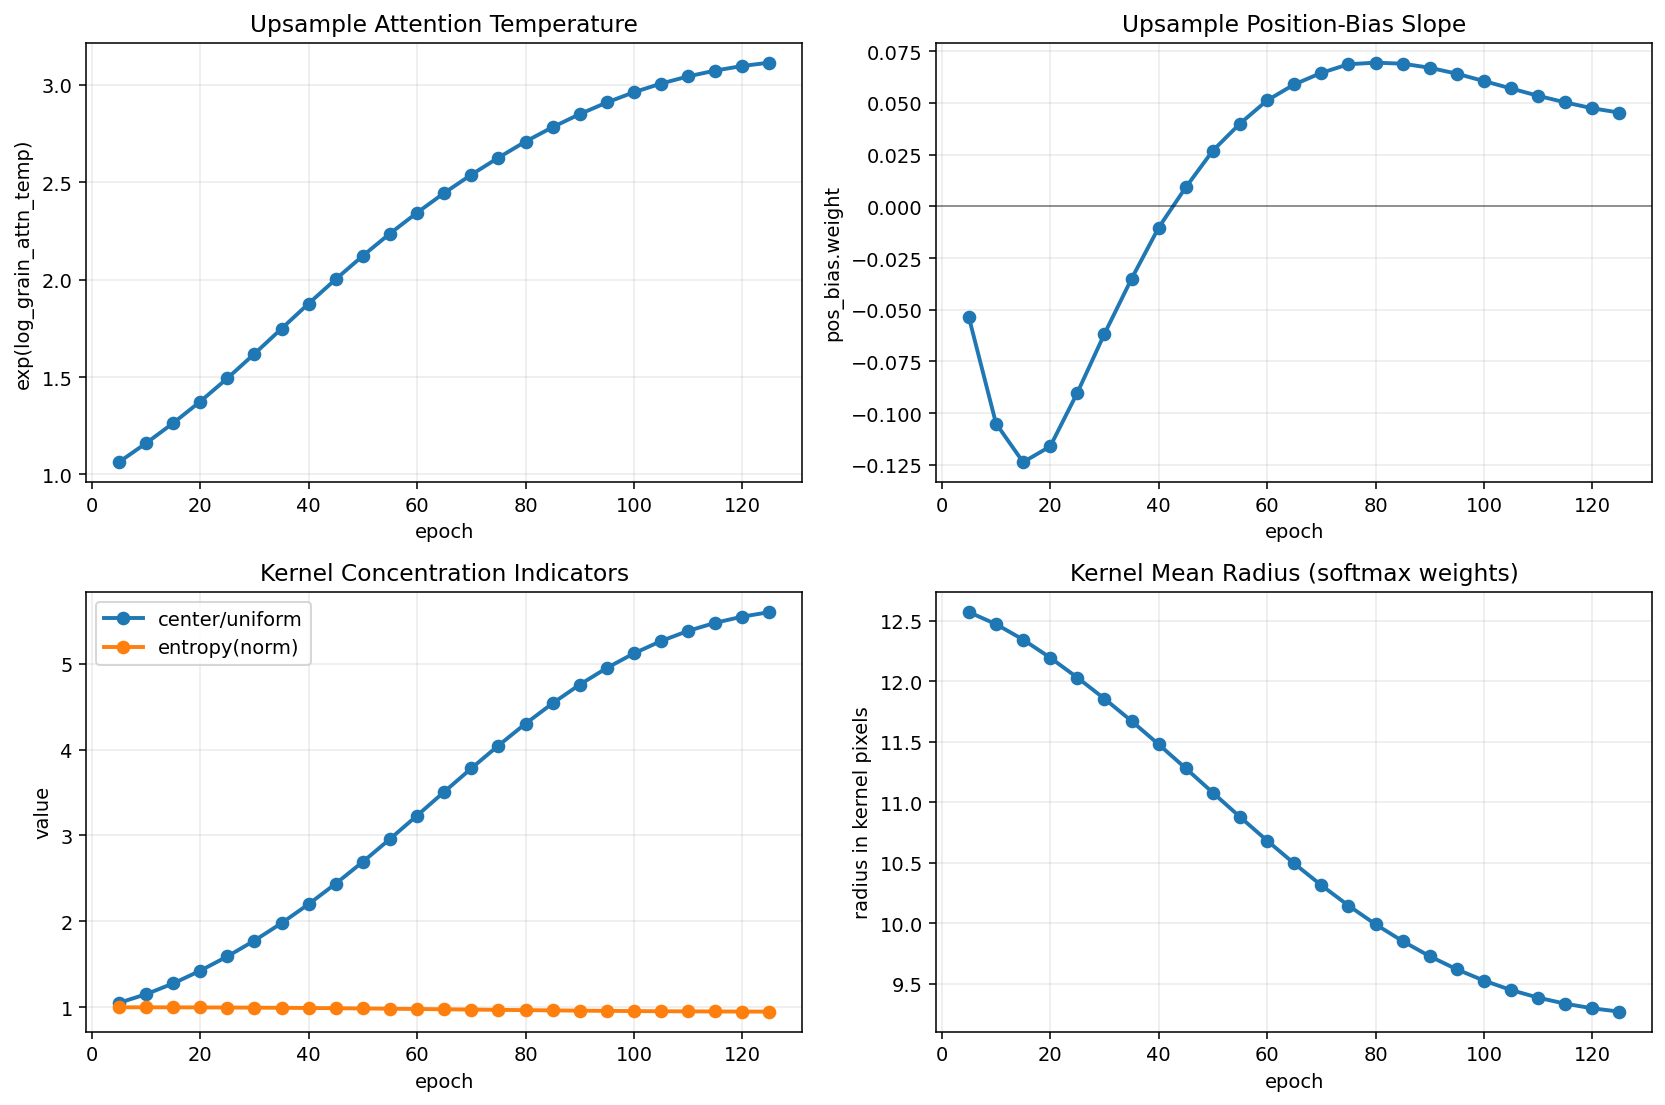

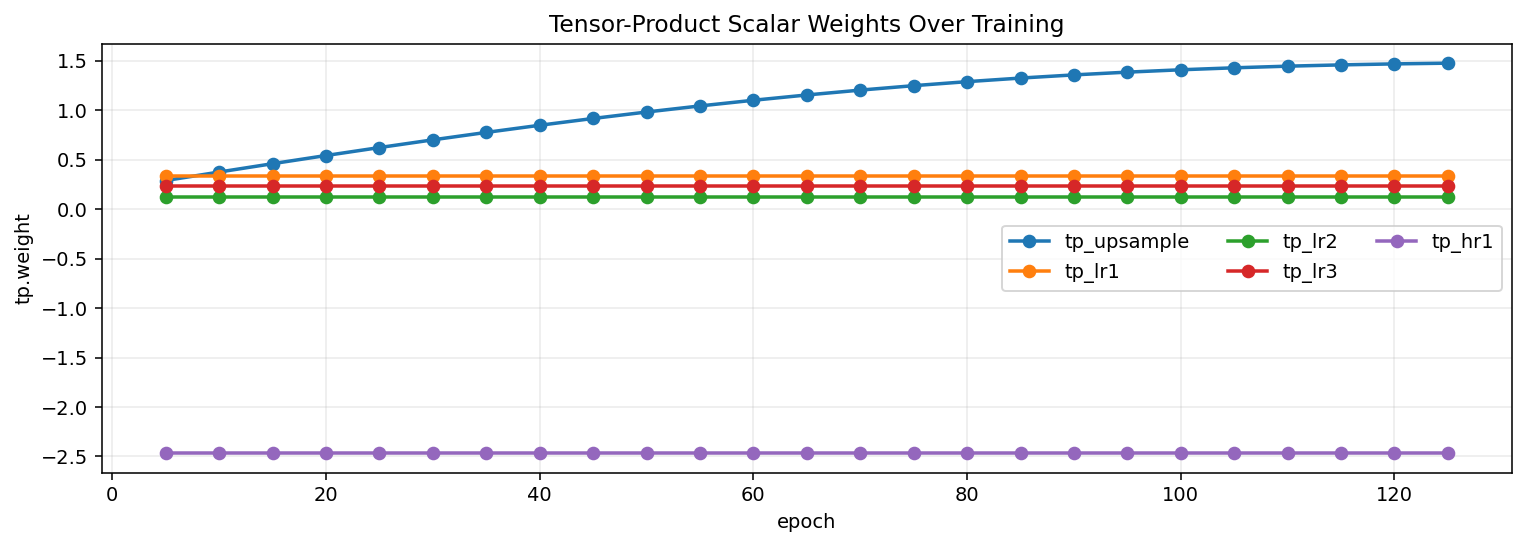

In [51]:
# Checkpoint trajectory: how key learned quantities evolve over training
import math
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ckpt_dir = EXP_DIR / "checkpoints"
if not ckpt_dir.exists():
    raise FileNotFoundError(f"Checkpoint dir not found: {ckpt_dir}")

epoch_files = sorted(ckpt_dir.glob("epoch_*.pt"))
if len(epoch_files) == 0:
    raise FileNotFoundError(f"No epoch_*.pt files found in {ckpt_dir}")

def _epoch_from_path(path: Path) -> int:
    m = re.search(r"epoch_(\d+)\.pt$", path.name)
    if not m:
        raise ValueError(path.name)
    return int(m.group(1))

def _state_from_ckpt(path: Path) -> dict[str, torch.Tensor]:
    payload = torch.load(path, map_location="cpu")
    return payload.get("model_state_dict", payload.get("model_state", payload))

def _kernel_metrics_from_state(state: dict[str, torch.Tensor], key: str):
    w = state[key].detach().float().cpu()
    H, W = int(w.shape[0]), int(w.shape[1])
    p = torch.softmax(w.reshape(-1), dim=0).reshape(H, W)
    cy, cx = H // 2, W // 2
    uniform = 1.0 / float(H * W)
    center_prob = float(p[cy, cx].item())
    center_ratio = center_prob / uniform
    ent = float((-(p * torch.log(p.clamp_min(1e-12))).sum() / math.log(H * W)).item())
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
    rr = torch.sqrt((yy - cy).float() ** 2 + (xx - cx).float() ** 2)
    mean_r = float((p * rr).sum().item())
    return center_prob, center_ratio, ent, mean_r

rows = []
for fp in epoch_files:
    e = _epoch_from_path(fp)
    st = _state_from_ckpt(fp)

    cprob, cratio, ent, mean_r = _kernel_metrics_from_state(st, "upsample_conv.spatial_weights")

    rows.append({
        "epoch": e,
        "temp": float(torch.exp(st["upsample_conv.log_grain_attn_temp"].detach().float()).item()),
        "pos_w": float(st["upsample_conv.pos_bias.weight"].detach().float().reshape(-1)[0].item()),
        "pos_b": float(st["upsample_conv.pos_bias.bias"].detach().float().reshape(-1)[0].item()),
        "tp_up": float(st["upsample_conv.tp.weight"].detach().float().reshape(-1)[0].item()),
        "tp_lr1": float(st["conv_lr1.tp.weight"].detach().float().reshape(-1)[0].item()) if "conv_lr1.tp.weight" in st else np.nan,
        "tp_lr2": float(st["conv_lr2.tp.weight"].detach().float().reshape(-1)[0].item()) if "conv_lr2.tp.weight" in st else np.nan,
        "tp_lr3": float(st["conv_lr3.tp.weight"].detach().float().reshape(-1)[0].item()) if "conv_lr3.tp.weight" in st else np.nan,
        "tp_hr1": float(st["conv_hr1.tp.weight"].detach().float().reshape(-1)[0].item()) if "conv_hr1.tp.weight" in st else np.nan,
        "kernel_center_prob": cprob,
        "kernel_center_ratio": cratio,
        "kernel_entropy_norm": ent,
        "kernel_mean_radius": mean_r,
    })

df_ckpt_metrics = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
display(df_ckpt_metrics)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=140)
ax = axes[0, 0]
ax.plot(df_ckpt_metrics["epoch"], df_ckpt_metrics["temp"], marker="o", linewidth=2)
ax.set_title("Upsample Attention Temperature")
ax.set_xlabel("epoch")
ax.set_ylabel("exp(log_grain_attn_temp)")
ax.grid(alpha=0.25)

ax = axes[0, 1]
ax.plot(df_ckpt_metrics["epoch"], df_ckpt_metrics["pos_w"], marker="o", linewidth=2)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.4)
ax.set_title("Upsample Position-Bias Slope")
ax.set_xlabel("epoch")
ax.set_ylabel("pos_bias.weight")
ax.grid(alpha=0.25)

ax = axes[1, 0]
ax.plot(df_ckpt_metrics["epoch"], df_ckpt_metrics["kernel_center_ratio"], marker="o", linewidth=2, label="center/uniform")
ax.plot(df_ckpt_metrics["epoch"], df_ckpt_metrics["kernel_entropy_norm"], marker="o", linewidth=2, label="entropy(norm)")
ax.set_title("Kernel Concentration Indicators")
ax.set_xlabel("epoch")
ax.set_ylabel("value")
ax.legend()
ax.grid(alpha=0.25)

ax = axes[1, 1]
ax.plot(df_ckpt_metrics["epoch"], df_ckpt_metrics["kernel_mean_radius"], marker="o", linewidth=2)
ax.set_title("Kernel Mean Radius (softmax weights)")
ax.set_xlabel("epoch")
ax.set_ylabel("radius in kernel pixels")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(11, 4), dpi=140)
for col, label in [
    ("tp_up", "tp_upsample"),
    ("tp_lr1", "tp_lr1"),
    ("tp_lr2", "tp_lr2"),
    ("tp_lr3", "tp_lr3"),
    ("tp_hr1", "tp_hr1"),
]:
    if col in df_ckpt_metrics:
        ax.plot(df_ckpt_metrics["epoch"], df_ckpt_metrics[col], marker="o", linewidth=1.8, label=label)
ax.set_title("Tensor-Product Scalar Weights Over Training")
ax.set_xlabel("epoch")
ax.set_ylabel("tp.weight")
ax.grid(alpha=0.25)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()



/tmp/ipykernel_1243496/772894191.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location="cpu")


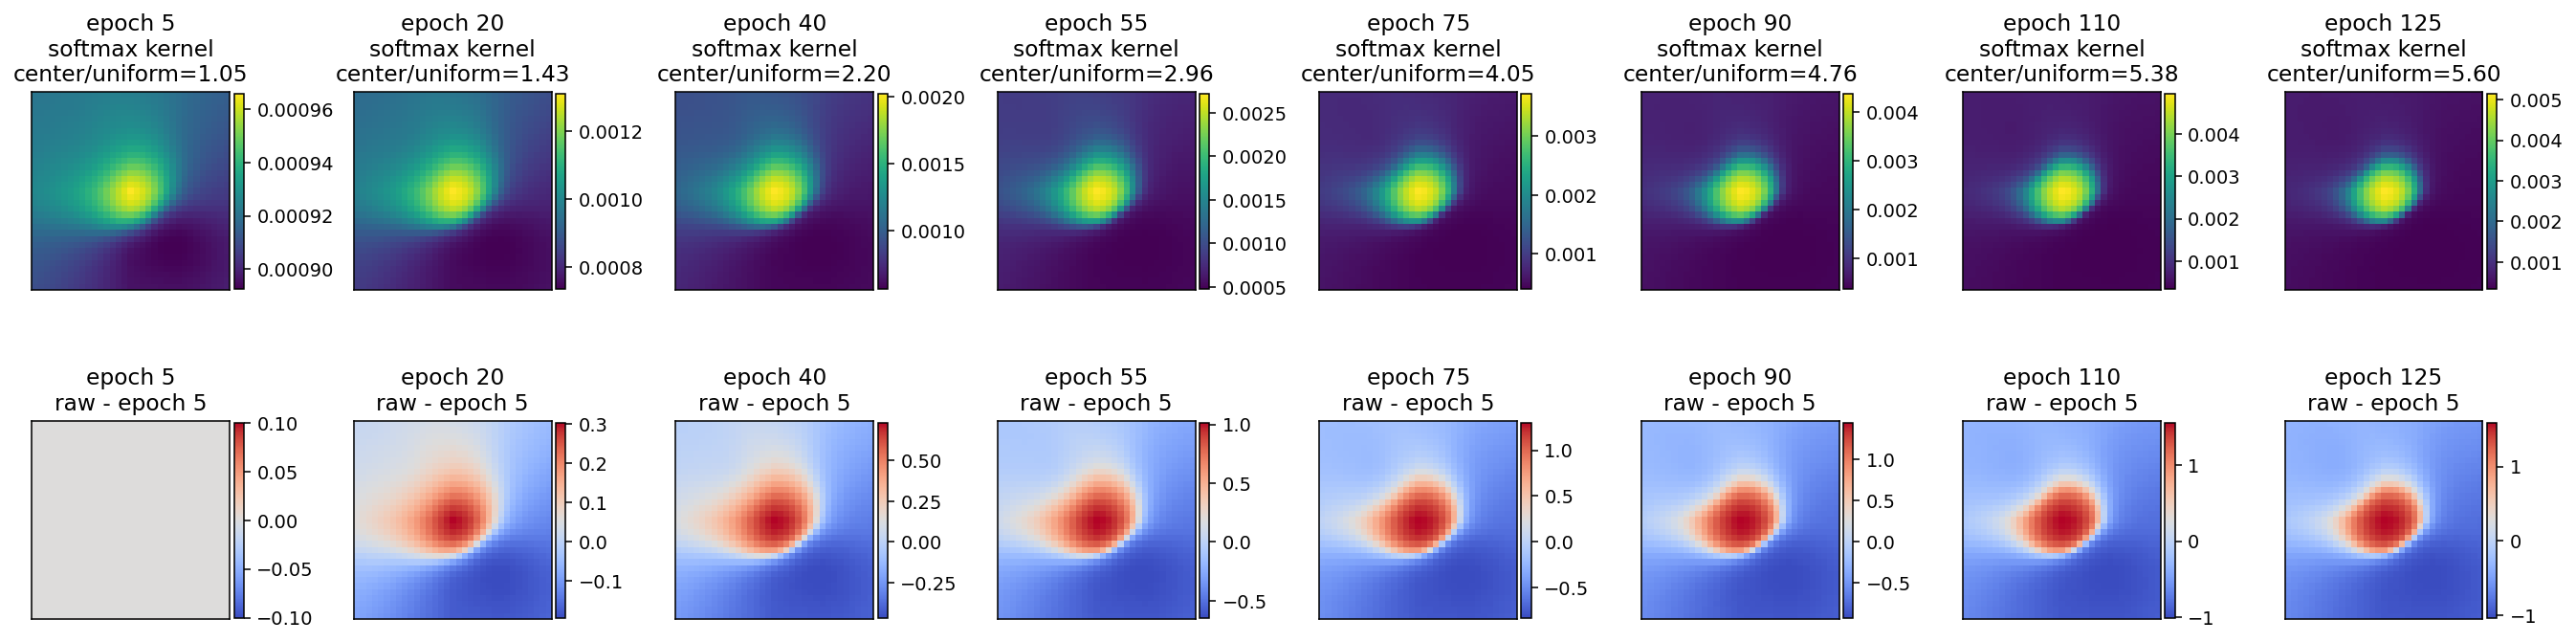

In [52]:
# Upsample spatial-kernel evolution as heatmaps (selected checkpoints)
import numpy as np
import matplotlib.pyplot as plt
import torch

if "df_ckpt_metrics" not in globals():
    raise RuntimeError("Run the checkpoint-trajectory cell first.")

ckpt_dir = EXP_DIR / "checkpoints"
all_epochs = df_ckpt_metrics["epoch"].to_numpy(dtype=int)

# Pick representative epochs across training.
if len(all_epochs) <= 8:
    pick_epochs = list(all_epochs)
else:
    idx = np.linspace(0, len(all_epochs) - 1, 8).round().astype(int)
    pick_epochs = [int(all_epochs[i]) for i in idx]

pick_paths = [ckpt_dir / f"epoch_{e:04d}.pt" for e in pick_epochs]

def _state(path):
    payload = torch.load(path, map_location="cpu")
    return payload.get("model_state_dict", payload.get("model_state", payload))

soft_kernels = []
raw_kernels = []
for p in pick_paths:
    st = _state(p)
    w = st["upsample_conv.spatial_weights"].detach().float().cpu()
    raw_kernels.append(w.numpy())
    soft_kernels.append(torch.softmax(w.reshape(-1), dim=0).reshape_as(w).numpy())

base_raw = raw_kernels[0]

fig, axes = plt.subplots(2, len(pick_epochs), figsize=(2.4 * len(pick_epochs), 5.4), dpi=140)
if len(pick_epochs) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, (e, pker, rker) in enumerate(zip(pick_epochs, soft_kernels, raw_kernels)):
    ax = axes[0, i]
    im = ax.imshow(pker, cmap="viridis")
    H, W = pker.shape
    center_ratio = float(pker[H // 2, W // 2] / (1.0 / (H * W)))
    ax.set_title(f"epoch {e}\nsoftmax kernel\ncenter/uniform={center_ratio:.2f}")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    ax = axes[1, i]
    d = rker - base_raw
    im = ax.imshow(d, cmap="coolwarm")
    ax.set_title(f"epoch {e}\nraw - epoch {pick_epochs[0]}")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()



/tmp/ipykernel_1243496/3654440575.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location="cpu")


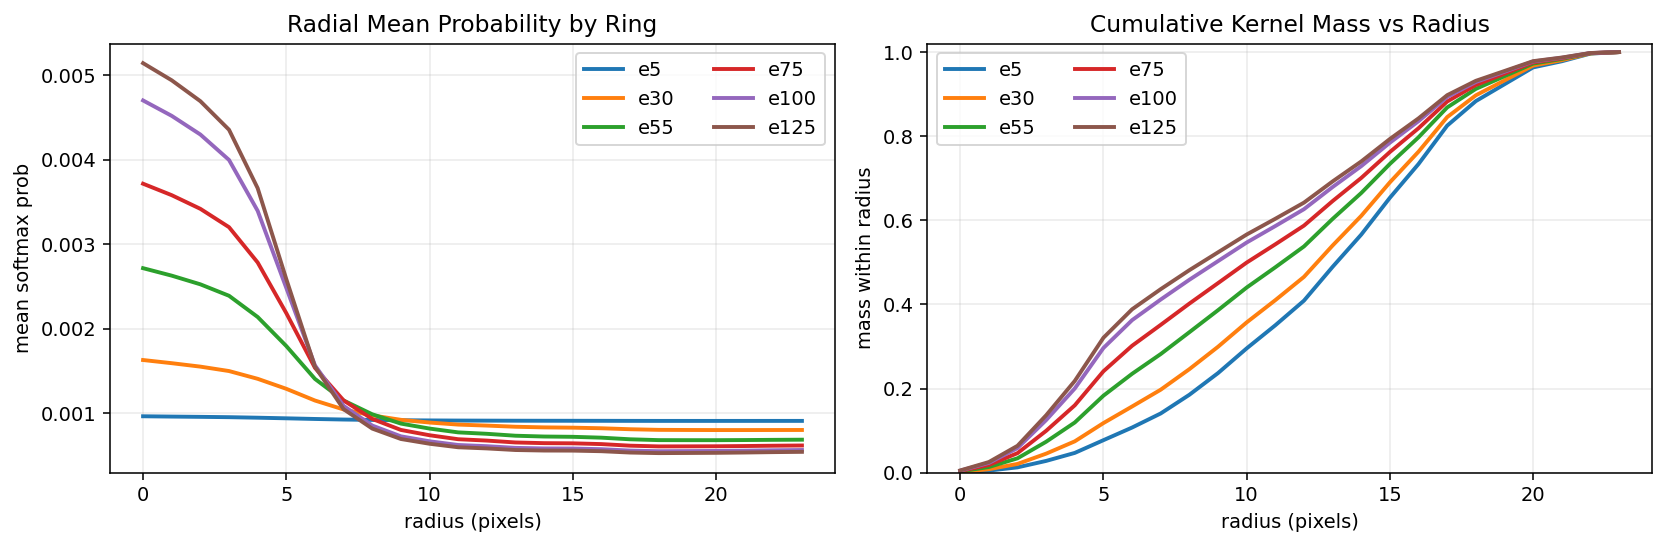

In [53]:
# Radial-profile evolution: where kernel mass is concentrated
import numpy as np
import matplotlib.pyplot as plt
import torch

if "df_ckpt_metrics" not in globals():
    raise RuntimeError("Run the checkpoint-trajectory cell first.")

ckpt_dir = EXP_DIR / "checkpoints"
all_epochs = df_ckpt_metrics["epoch"].to_numpy(dtype=int)
if len(all_epochs) <= 6:
    pick_epochs = list(all_epochs)
else:
    idx = np.linspace(0, len(all_epochs) - 1, 6).round().astype(int)
    pick_epochs = [int(all_epochs[i]) for i in idx]

def _soft_kernel(path):
    payload = torch.load(path, map_location="cpu")
    st = payload.get("model_state_dict", payload.get("model_state", payload))
    w = st["upsample_conv.spatial_weights"].detach().float().cpu()
    return torch.softmax(w.reshape(-1), dim=0).reshape_as(w)

def _radial_stats(p: torch.Tensor):
    H, W = int(p.shape[0]), int(p.shape[1])
    cy, cx = H // 2, W // 2
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
    rr = torch.sqrt((yy - cy).float() ** 2 + (xx - cx).float() ** 2)
    rb = rr.round().long()
    rmax = int(rb.max().item())

    prof = []
    cdf = []
    for r in range(rmax + 1):
        m = rb == r
        prof.append(float(p[m].mean().item()) if bool(m.any()) else np.nan)
        cdf.append(float(p[rr <= float(r)].sum().item()))
    return np.arange(rmax + 1), np.array(prof), np.array(cdf)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)
for e in pick_epochs:
    p = _soft_kernel(ckpt_dir / f"epoch_{e:04d}.pt")
    r, prof, cdf = _radial_stats(p)
    axes[0].plot(r, prof, linewidth=2, label=f"e{e}")
    axes[1].plot(r, cdf, linewidth=2, label=f"e{e}")

axes[0].set_title("Radial Mean Probability by Ring")
axes[0].set_xlabel("radius (pixels)")
axes[0].set_ylabel("mean softmax prob")
axes[0].grid(alpha=0.25)

axes[1].set_title("Cumulative Kernel Mass vs Radius")
axes[1].set_xlabel("radius (pixels)")
axes[1].set_ylabel("mass within radius")
axes[1].set_ylim(0.0, 1.02)
axes[1].grid(alpha=0.25)

axes[0].legend(ncol=2)
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()



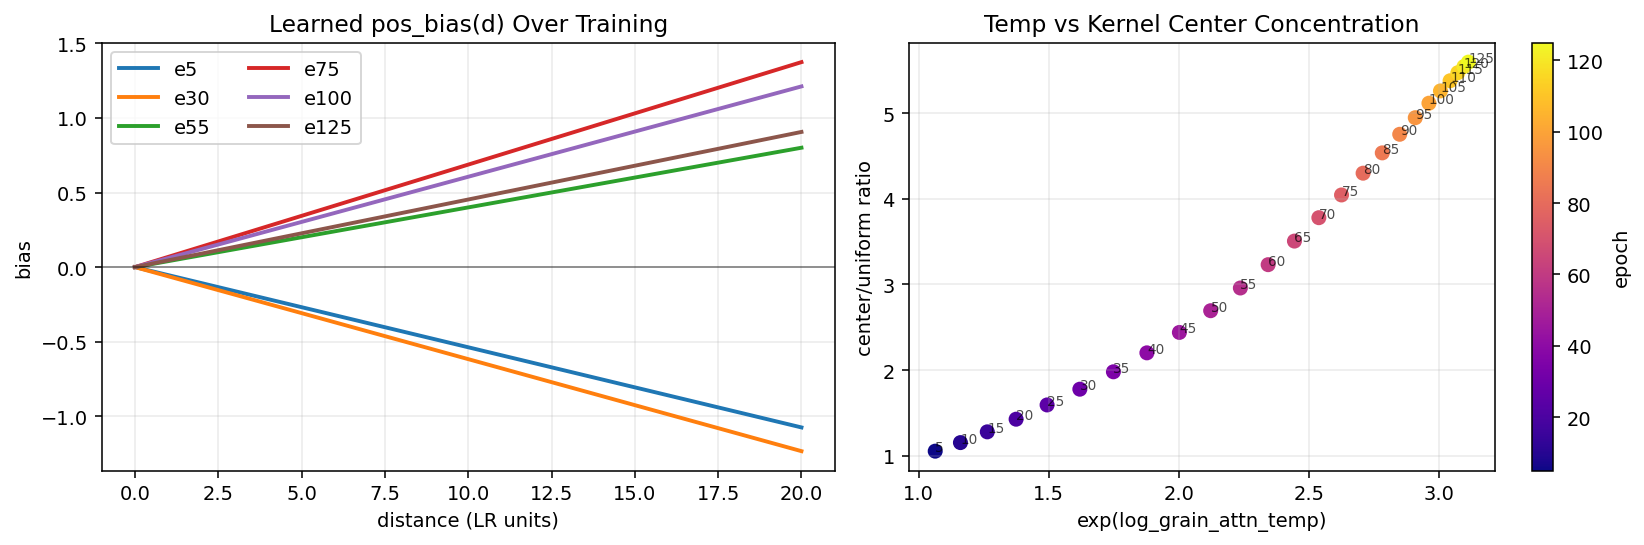

In [54]:
# Positional-bias behavior over training + coupling with kernel concentration
import numpy as np
import matplotlib.pyplot as plt

if "df_ckpt_metrics" not in globals():
    raise RuntimeError("Run the checkpoint-trajectory cell first.")

df = df_ckpt_metrics.copy()

# Distance response curves using y(d)=w*d+b for selected checkpoints.
ckpt_dir = EXP_DIR / "checkpoints"
all_epochs = df["epoch"].to_numpy(dtype=int)
if len(all_epochs) <= 6:
    pick_epochs = list(all_epochs)
else:
    idx = np.linspace(0, len(all_epochs) - 1, 6).round().astype(int)
    pick_epochs = [int(all_epochs[i]) for i in idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

d = np.linspace(0.0, 20.0, 200)
for e in pick_epochs:
    row = df[df["epoch"] == e].iloc[0]
    w = float(row["pos_w"])
    b = float(row["pos_b"])
    y = w * d + b
    axes[0].plot(d, y, linewidth=2, label=f"e{e}")

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.4)
axes[0].set_title("Learned pos_bias(d) Over Training")
axes[0].set_xlabel("distance (LR units)")
axes[0].set_ylabel("bias")
axes[0].grid(alpha=0.25)
axes[0].legend(ncol=2)

# Coupling plot: as temperature rises, kernel tends to concentrate.
sc = axes[1].scatter(
    df["temp"],
    df["kernel_center_ratio"],
    c=df["epoch"],
    cmap="plasma",
    s=45,
)
for _, r in df.iterrows():
    axes[1].annotate(int(r["epoch"]), (r["temp"], r["kernel_center_ratio"]), fontsize=7, alpha=0.7)
axes[1].set_title("Temp vs Kernel Center Concentration")
axes[1].set_xlabel("exp(log_grain_attn_temp)")
axes[1].set_ylabel("center/uniform ratio")
axes[1].grid(alpha=0.25)
cb = plt.colorbar(sc, ax=axes[1])
cb.set_label("epoch")

plt.tight_layout()
plt.show()

